In [1]:
!python -V

Python 3.10.20


In [2]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [6]:
# !wget 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-01.parquet'
# !wget 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2022-06.parquet'

In [7]:
import mlflow 
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi")

<Experiment: artifact_location='/home/eng_39_0072/Desktop/ML/mlruns/2', creation_time=1774298922611, experiment_id='2', last_update_time=1774298922611, lifecycle_stage='active', name='nyc-taxi', tags={}, workspace='default'>

In [8]:
df = pd.read_parquet('data/yellow_tripdata_2022-01.parquet')

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [9]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

7.00149617945435

/tmp/ipykernel_2986823/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_2986823/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


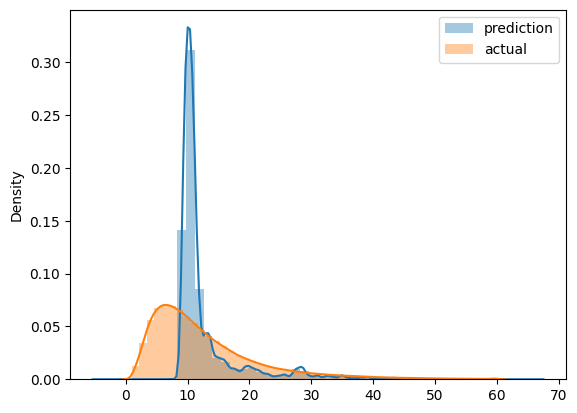

In [10]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [11]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [12]:
df_train = read_dataframe('data/yellow_tripdata_2022-01.parquet')
df_val = read_dataframe('data/yellow_tripdata_2022-06.parquet')

In [13]:
len(df_train), len(df_val)

(2421440, 3430743)

In [14]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [15]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [16]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.549340749168065

In [18]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [19]:
with mlflow.start_run(run_name = "Lasso reg"):
    alpha = 0.01
    mlflow.log_param("alpha" , alpha)
    mlflow.log_param("train-data-path" , "./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("val-data-path" , "./data/green_tripdata_2021-02.parquet")
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse" , rmse)

In [20]:
import xgboost as xgb
from hyperopt import fmin,tpe,hp,STATUS_OK,Trials
from hyperopt.pyll import scope
from sklearn.metrics import mean_squared_error

/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [21]:
X_train_sample = X_train[:50000]   # use 50k rows instead of all for smaller compute time 
y_train_sample = y_train[:50000]

X_val_sample = X_val[:20000]    
y_val_sample = y_val[:20000]


train = xgb.DMatrix(X_train_sample,label=y_train_sample)
valid = xgb.DMatrix(X_val_sample,label =y_val_sample)

In [24]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model" , "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params = params,
            dtrain = train,
            num_boost_round =100,
            evals = [(valid,"validation")],
            early_stopping_rounds = 50
        )

        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val_sample,y_pred)
        mlflow.log_metric("rmse",rmse)
    return{'loss':rmse , 'status':STATUS_OK}

In [25]:
search_space = {
    'max_depth' : scope.int(hp.quniform('max_depth', 4, 10, 1)),
    'learning_rate':hp.loguniform('learning_rate',-3,0), #exp(-3) and exp(0)
    'reg_alpha':hp.loguniform('reg_alpha',-5,-1),
    'reg_lambda':hp.loguniform('reg_lambda',-6,-1),
    'min_child_weight':hp.loguniform('min_child_weight',-1,3),
    'objective':'reg:linear',
    'seed':42
}

best_result=fmin(
    fn=objective,
    space = search_space,
    algo = tpe.suggest,
    max_evals = 15,
    trials=Trials()
)

  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]

/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [22:40:08] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.23520                           
[1]	validation-rmse:8.43154                           
[2]	validation-rmse:7.87083                           
[3]	validation-rmse:7.48092                           
[4]	validation-rmse:7.21175                           
[5]	validation-rmse:7.02767                           
[6]	validation-rmse:6.89545                           
[7]	validation-rmse:6.80279                           
[8]	validation-rmse:6.73650                           
[9]	validation-rmse:6.68922                           
[10]	validation-rmse:6.65760                          
[11]	validation-rmse:6.63626                          
[12]	validation-rmse:6.61661                          
[13]	validation-rmse:6.60397                          
[14]	validation-rmse:6.59691                          
[15]	validation-rmse:6.59115                          
[16]	validation-rmse:6.58521                          
[17]	validation-rmse:6.58131                          
[18]	valid

/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [22:41:11] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:9.33774                                                    
[1]	validation-rmse:8.58007                                                    
[2]	validation-rmse:8.02588                                                    
[3]	validation-rmse:7.62654                                                    
[4]	validation-rmse:7.33702                                                    
[5]	validation-rmse:7.13008                                                    
[6]	validation-rmse:6.98124                                                    
[7]	validation-rmse:6.87346                                                    
[8]	validation-rmse:6.79484                                                    
[9]	validation-rmse:6.73708                                                    
[10]	validation-rmse:6.69632                                                   
[11]	validation-rmse:6.66416                                                   
[12]	validation-rmse:6.64249            

...

[0]	validation-rmse:9.39939                                                     
[1]	validation-rmse:8.67028                                                     
[2]	validation-rmse:8.12395                                                     
[3]	validation-rmse:7.72217                                                     
[4]	validation-rmse:7.42409                                                     
[5]	validation-rmse:7.20622                                                     
[6]	validation-rmse:7.04601                                                     
[7]	validation-rmse:6.92782                                                     
[8]	validation-rmse:6.83826                                                     
[9]	validation-rmse:6.76906                                                     
[10]	validation-rmse:6.72118                                                    
[11]	validation-rmse:6.68101                                                    
[12]	validation-rmse:6.65209

/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [22:51:36] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.64449                                                     
[1]	validation-rmse:7.69828                                                     
[2]	validation-rmse:7.18921                                                     
[3]	validation-rmse:6.92304                                                     
[4]	validation-rmse:6.77550                                                     
[5]	validation-rmse:6.68875                                                     
[6]	validation-rmse:6.64031                                                     
[7]	validation-rmse:6.60952                                                     
[8]	validation-rmse:6.59401                                                     
[9]	validation-rmse:6.58035                                                     
[10]	validation-rmse:6.57437                                                    
[11]	validation-rmse:6.57151                                                    
[12]	validation-rmse:6.57222

/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [22:52:37] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:10.03270                                                    
[1]	validation-rmse:9.72950                                                     
[2]	validation-rmse:9.45070                                                     
[3]	validation-rmse:9.19587                                                     
[4]	validation-rmse:8.96207                                                     
[5]	validation-rmse:8.74811                                                     
[6]	validation-rmse:8.55253                                                     
[7]	validation-rmse:8.37381                                                     
[8]	validation-rmse:8.21066                                                     
[9]	validation-rmse:8.06145                                                     
[10]	validation-rmse:7.92567                                                    
[11]	validation-rmse:7.80143                                                    
[12]	validation-rmse:7.68831

In [26]:
params= {
    'learning_rate':0.3354600546607124,
    'max_depth':8,
    'min_child_weight':0.41561743041539617,
    'objective':'reg:linear',
    'reg_alpha':0.007616523667824497,
    'reg_lambda':0.011137501839762573,
    'seed':42}

mlflow.xgboost.autolog()

booster = xgb.train(
            params = params,
            dtrain = train,
            num_boost_round =100,
            evals = [(valid,"validation")],
            early_stopping_rounds = 50
        )

2026/03/23 23:00:29 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '23fff089496142b6a91ad7fb7d481bbe', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
/home/eng_39_0072/anaconda3/envs/mlops/lib/python3.10/site-packages/xgboost/callback.py:385: UserWarning: [23:00:35] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:8.64449
[1]	validation-rmse:7.69828
[2]	validation-rmse:7.18921
[3]	validation-rmse:6.92304
[4]	validation-rmse:6.77550
[5]	validation-rmse:6.68875
[6]	validation-rmse:6.64031
[7]	validation-rmse:6.60952
[8]	validation-rmse:6.59401
[9]	validation-rmse:6.58035
[10]	validation-rmse:6.57437
[11]	validation-rmse:6.57151
[12]	validation-rmse:6.57222
[13]	validation-rmse:6.57030
[14]	validation-rmse:6.57430
[15]	validation-rmse:6.57490
[16]	validation-rmse:6.57407
[17]	validation-rmse:6.57166
[18]	validation-rmse:6.57225
[19]	validation-rmse:6.57173
[20]	validation-rmse:6.56921
[21]	validation-rmse:6.57000
[22]	validation-rmse:6.56975
[23]	validation-rmse:6.56915
[24]	validation-rmse:6.56903
[25]	validation-rmse:6.56750
[26]	validation-rmse:6.56653
[27]	validation-rmse:6.56567
[28]	validation-rmse:6.56581
[29]	validation-rmse:6.56663
[30]	validation-rmse:6.56724
[31]	validation-rmse:6.56615
[32]	validation-rmse:6.56703
[33]	validation-rmse:6.56683
[34]	validation-rmse:6.5

2026/03/23 23:01:42 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/03/23 23:01:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
